In [9]:
import cx_Oracle


connection = cx_Oracle.connect(
    user="HR",
    password="HR",
    dsn="localhost/XEPDB1"  # Service Name you showed earlier
)


cursor = connection.cursor()


cursor.execute("SELECT * FROM employees FETCH FIRST 5 ROWS ONLY")
for row in cursor:
    print(row)


cursor.close()
connection.close()


(100, 'Steven', 'King', 'SKING', '515.123.4567', datetime.datetime(2003, 6, 17, 0, 0), 'AD_PRES', 24000.0, None, None, 90)
(101, 'Neena', 'Kochhar', 'NKOCHHAR', '515.123.4568', datetime.datetime(2005, 9, 21, 0, 0), 'AD_VP', 17000.0, None, 102, 90)
(102, 'Lex', 'De Haan', 'LDEHAAN', '515.123.4569', datetime.datetime(2001, 1, 13, 0, 0), 'AD_VP', 17000.0, None, None, 90)
(103, 'Alexander', 'Hunold', 'AHUNOLD', '590.423.4567', datetime.datetime(2006, 1, 3, 0, 0), 'IT_PROG', 9000.0, None, 104, 60)
(104, 'Bruce', 'Ernst', 'BERNST', '590.423.4568', datetime.datetime(2007, 5, 21, 0, 0), 'IT_PROG', 6000.0, None, None, 60)


In [11]:
import pandas as pd
from sqlalchemy import create_engine

# Create engine (SQLAlchemy + cx_Oracle)
engine = create_engine('oracle+cx_oracle://HR:HR@localhost:1521/?service_name=XEPDB1')

# Load tables
employees_df = pd.read_sql("SELECT * FROM employees", con=engine)
departments_df = pd.read_sql("SELECT * FROM departments", con=engine)
jobs_df = pd.read_sql("SELECT * FROM jobs", con=engine)
locations_df = pd.read_sql("SELECT * FROM locations", con=engine)
countries_df = pd.read_sql("SELECT * FROM countries", con=engine)
regions_df = pd.read_sql("SELECT * FROM regions", con=engine)
job_history_df = pd.read_sql("SELECT * FROM job_history", con=engine)


In [12]:
pip install SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


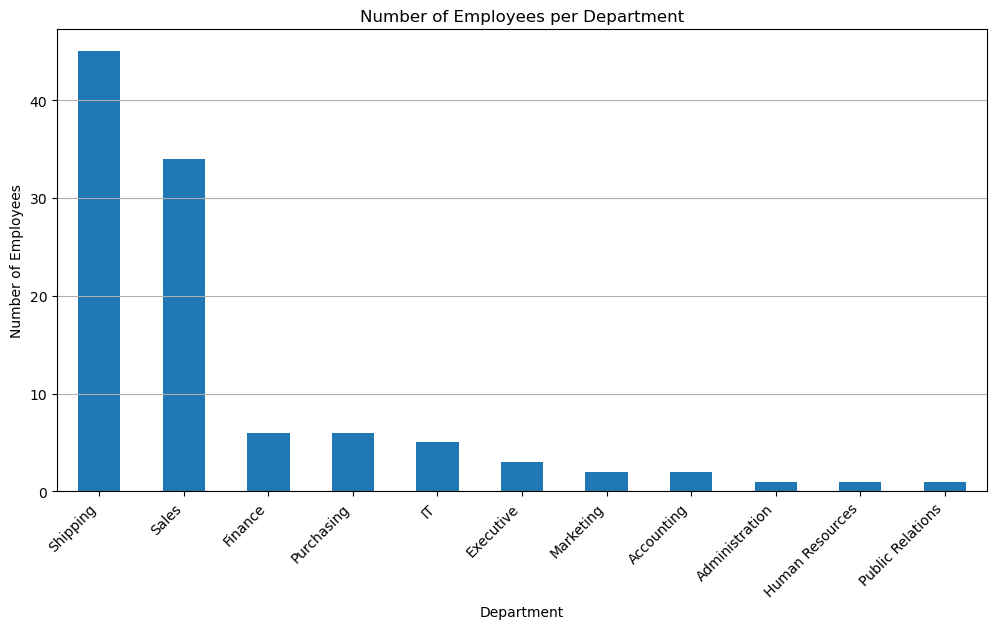

In [13]:
#  Standardize column names (force all uppercase and remove spaces)
employees_df.columns = employees_df.columns.str.upper().str.strip()
departments_df.columns = departments_df.columns.str.upper().str.strip()

# Merge employees and departments
emp_dept_df = employees_df.merge(departments_df, on='DEPARTMENT_ID', how='left')

# Group and plot
emp_by_dept = emp_dept_df['DEPARTMENT_NAME'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
emp_by_dept.plot(kind='bar')
plt.title('Number of Employees per Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()


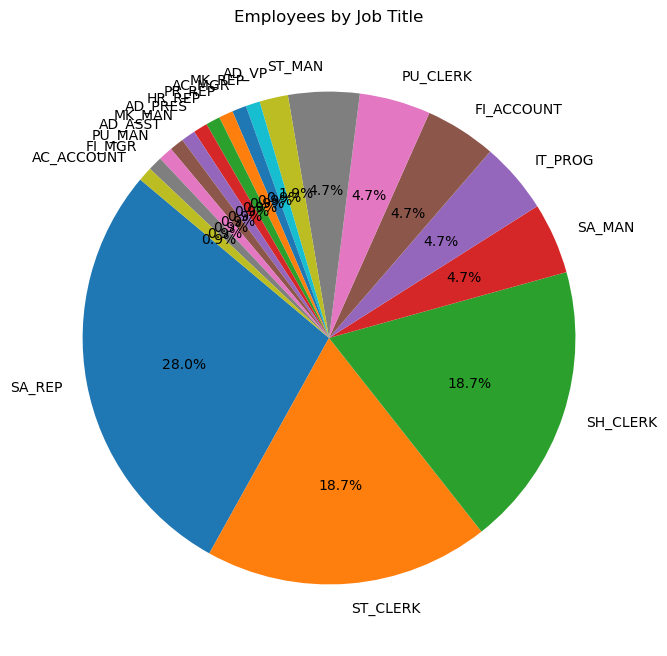

In [14]:
# Group employees by job title
emp_by_job = employees_df['JOB_ID'].value_counts()

# Plot
plt.figure(figsize=(8,8))
emp_by_job.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Employees by Job Title')
plt.ylabel('')  # hide y-label
plt.show()


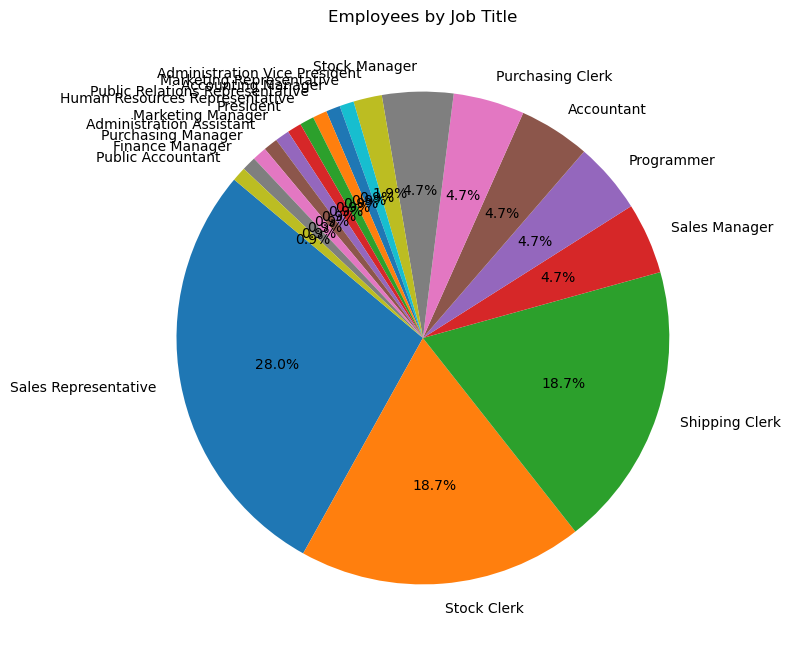

In [16]:
# Clean the columns first
employees_df.columns = employees_df.columns.str.upper().str.strip()
jobs_df.columns = jobs_df.columns.str.upper().str.strip()

# merge
emp_job_df = employees_df.merge(jobs_df, on='JOB_ID', how='left')

# Group by readable Job Titles
emp_by_jobtitle = emp_job_df['JOB_TITLE'].value_counts()

# Plot
plt.figure(figsize=(10,8))
emp_by_jobtitle.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Employees by Job Title')
plt.ylabel('')
plt.show()


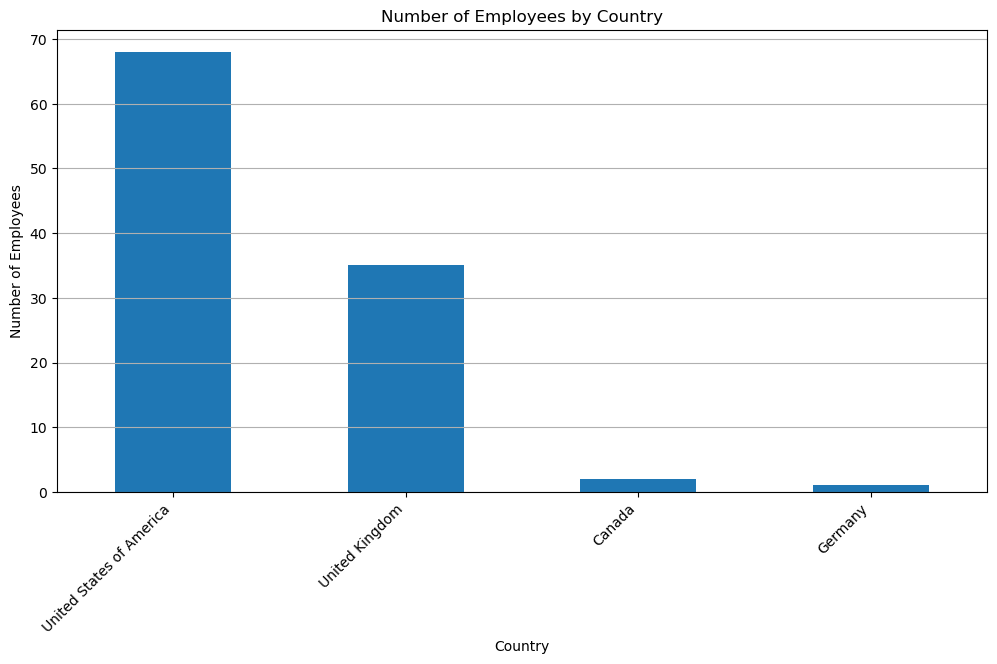

In [21]:
# Clean columns
departments_df.columns = departments_df.columns.str.upper().str.strip()
locations_df.columns = locations_df.columns.str.upper().str.strip()
countries_df.columns = countries_df.columns.str.upper().str.strip()

# Merge employees -> departments
emp_dept = employees_df.merge(departments_df, on='DEPARTMENT_ID', how='left')

# Merge emp_dept -> locations
emp_dept_loc = emp_dept.merge(locations_df, on='LOCATION_ID', how='left')

# Merge emp_dept_loc -> countries
emp_dept_loc_countries = emp_dept_loc.merge(countries_df, on='COUNTRY_ID', how='left')

# Group by COUNTRY_NAME
emp_by_country = emp_dept_loc_countries['COUNTRY_NAME'].value_counts()

# Plot
plt.figure(figsize=(12,6))
emp_by_country.plot(kind='bar')
plt.title('Number of Employees by Country')
plt.xlabel('Country')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()


In [23]:
# Clean columns
employees_df.columns = employees_df.columns.str.upper().str.strip()
departments_df.columns = departments_df.columns.str.upper().str.strip()
jobs_df.columns = jobs_df.columns.str.upper().str.strip()

# Merge employees -> departments (get department names)
emp_dept_salary = employees_df.merge(departments_df, on='DEPARTMENT_ID', how='left')

# Merge that -> jobs (get job titles and salary ranges)
emp_dept_job_salary = emp_dept_salary.merge(jobs_df, on='JOB_ID', how='left')

# preview
emp_dept_job_salary[['FIRST_NAME', 'LAST_NAME', 'DEPARTMENT_NAME', 'JOB_TITLE', 'SALARY']].head()


,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,JOB_TITLE,SALARY
0,Steven,King,Executive,President,24000.0
1,Neena,Kochhar,Executive,Administration Vice President,17000.0
2,Lex,De Haan,Executive,Administration Vice President,17000.0
3,Alexander,Hunold,IT,Programmer,9000.0
4,Bruce,Ernst,IT,Programmer,6000.0


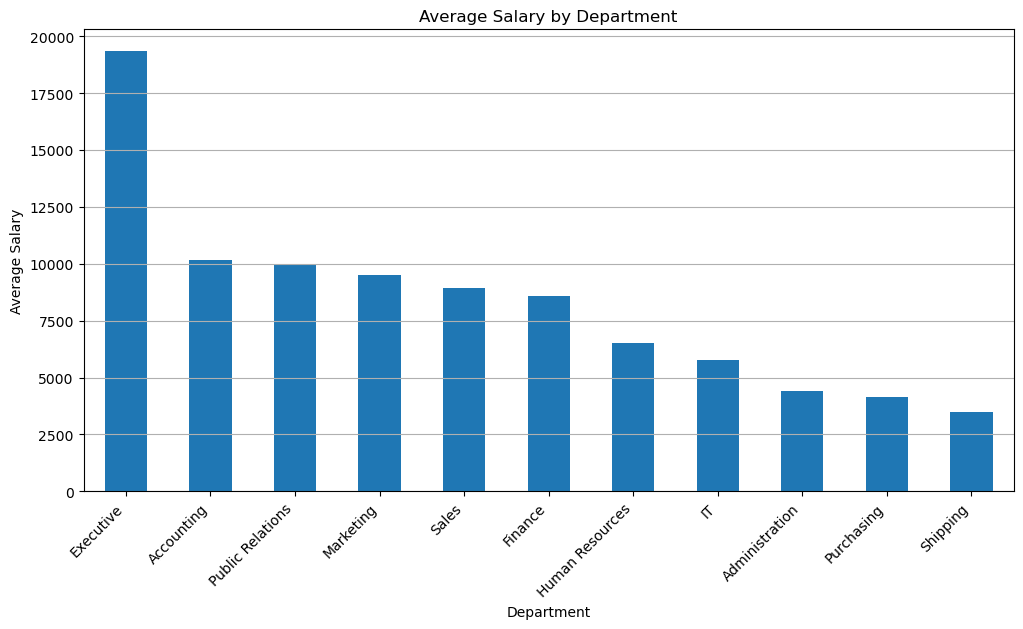

In [25]:
# Group and plot
avg_salary_by_dept = emp_dept_job_salary.groupby('DEPARTMENT_NAME')['SALARY'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_salary_by_dept.plot(kind='bar')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()


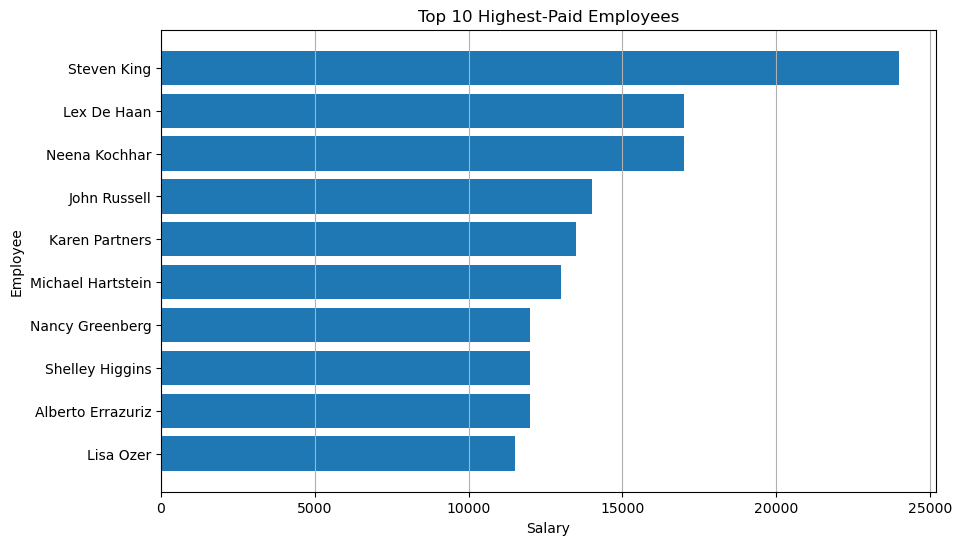

,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,JOB_TITLE,SALARY
0,Steven,King,Executive,President,24000.0
2,Lex,De Haan,Executive,Administration Vice President,17000.0
1,Neena,Kochhar,Executive,Administration Vice President,17000.0
45,John,Russell,Sales,Sales Manager,14000.0
46,Karen,Partners,Sales,Sales Manager,13500.0
101,Michael,Hartstein,Marketing,Marketing Manager,13000.0
8,Nancy,Greenberg,Finance,Finance Manager,12008.0
105,Shelley,Higgins,Accounting,Accounting Manager,12008.0
47,Alberto,Errazuriz,Sales,Sales Manager,12000.0
68,Lisa,Ozer,Sales,Sales Representative,11500.0


In [27]:
# 1. Sort by salary
top_earners = emp_dept_job_salary[['FIRST_NAME', 'LAST_NAME', 'DEPARTMENT_NAME', 'JOB_TITLE', 'SALARY']].sort_values(by='SALARY', ascending=False).head(10)

# 2. Plot
plt.figure(figsize=(10,6))
plt.barh(
    top_earners['FIRST_NAME'] + " " + top_earners['LAST_NAME'], 
    top_earners['SALARY']
)
plt.title('Top 10 Highest-Paid Employees')
plt.xlabel('Salary')
plt.ylabel('Employee')
plt.gca().invert_yaxis()  # Highest salary at the top
plt.grid(axis='x')
plt.show()

# 3. Show the table too
top_earners


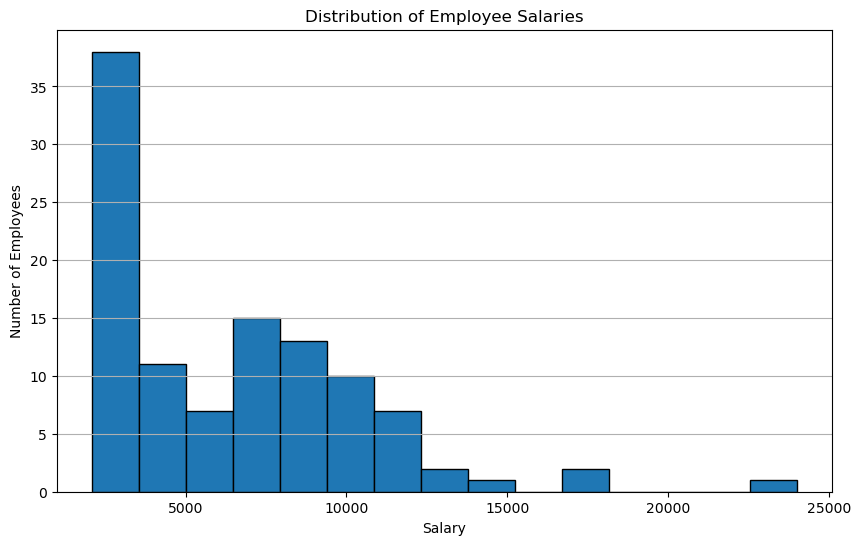

In [29]:
# Plot Salary Distribution
plt.figure(figsize=(10,6))
plt.hist(emp_dept_job_salary['SALARY'], bins=15, edgecolor='black')
plt.title('Distribution of Employee Salaries')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.grid(axis='y')
plt.show()

In [31]:
print(employees_df.isnull().sum())
print(departments_df.isnull().sum())
print(jobs_df.isnull().sum())
print(locations_df.isnull().sum())
print(countries_df.isnull().sum())
print(regions_df.isnull().sum())
print(job_history_df.isnull().sum())

EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
EMAIL              0
PHONE_NUMBER       0
HIRE_DATE          0
JOB_ID             0
SALARY             0
COMMISSION_PCT    72
MANAGER_ID         3
DEPARTMENT_ID      1
dtype: int64
DEPARTMENT_ID       0
DEPARTMENT_NAME     0
MANAGER_ID         16
LOCATION_ID         0
dtype: int64
JOB_ID        0
JOB_TITLE     0
MIN_SALARY    0
MAX_SALARY    0
dtype: int64
LOCATION_ID       0
STREET_ADDRESS    0
POSTAL_CODE       1
CITY              0
STATE_PROVINCE    6
COUNTRY_ID        0
dtype: int64
COUNTRY_ID      0
COUNTRY_NAME    0
REGION_ID       0
dtype: int64
region_id      0
region_name    0
dtype: int64
employee_id      0
start_date       0
end_date         0
job_id           0
department_id    0
dtype: int64


In [33]:
# Fill missing COMMISSION_PCT with 0
employees_df['COMMISSION_PCT'] = employees_df['COMMISSION_PCT'].fillna(0)

# Fill missing MANAGER_ID with 'Unknown'
employees_df['MANAGER_ID'] = employees_df['MANAGER_ID'].fillna('Unknown')

# Fill missing DEPARTMENT_ID in employees with 'Unknown'
employees_df['DEPARTMENT_ID'] = employees_df['DEPARTMENT_ID'].fillna('Unknown')

# Fill missing LOCATION_ID in departments with 'Unknown'
departments_df['LOCATION_ID'] = departments_df['LOCATION_ID'].fillna('Unknown')

In [35]:
# Fix only where needed
locations_df['POSTAL_CODE'].fillna('Unknown', inplace=True)
locations_df['STATE_PROVINCE'].fillna('Unknown', inplace=True)

C:\Users\diont\AppData\Local\Temp\ipykernel_31628\2848878729.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  locations_df['POSTAL_CODE'].fillna('Unknown', inplace=True)
C:\Users\diont\AppData\Local\Temp\ipykernel_31628\2848878729.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [37]:
employees_df.to_csv('employees_cleaned.csv', index=False)
locations_df.to_csv('locations_cleaned.csv', index=False)

In [39]:
# Fix missing MANAGER_ID by filling with 0
departments_df['MANAGER_ID'] = departments_df['MANAGER_ID'].fillna(0)

# Export the cleaned file
departments_df.to_csv('departments_cleaned.csv', index=False)

In [43]:
employees_df.to_csv('employees_cleaned.csv', index=False)
departments_df.to_csv('departments_cleaned.csv', index=False)
jobs_df.to_csv('jobs_cleaned.csv', index=False)
locations_df.to_csv('locations_cleaned.csv', index=False)
countries_df.to_csv('countries_cleaned.csv', index=False)
regions_df.to_csv('regions_cleaned.csv', index=False)
job_history_df.to_csv('job_history_cleaned.csv', index=False)